In [9]:
# IMPORTS
import pickle
import random
import sys
import warnings
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bayes_opt import BayesianOptimization
from bayes_opt.event import Events
from bayes_opt.logger import JSONLogger
from river import anomaly, compose, time_series
from river.metrics import MAE

sys.path.insert(1, str(Path.cwd().parent))
from functions.compose import (
    build_model,
    convert_to_nested_dict,
)
from functions.evaluate import (
    build_fit_evaluate,
    progressive_val_predict,
)
from publications.ilustrate.pc2023.plot_matplotlib import (
    formatter,
    locator,
    set_size,
)


=== terra === [8197.166942148067/12497]========================================

===== AR=======================================================================


KeyboardInterrupt: 

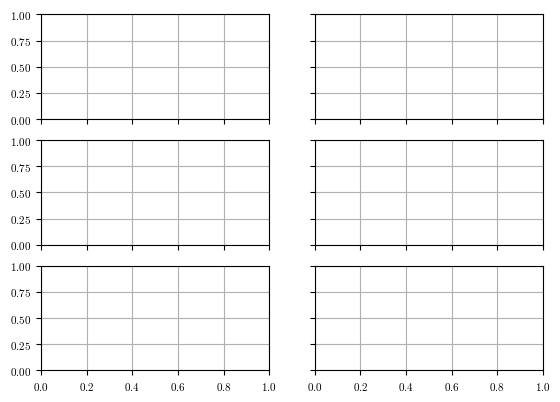

In [8]:
# CONSTANTS
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)


# FUNCTIONS
def get_time_features(_x: dict[str, float]) -> dict[str, float]:
    """Return an empty dict (time features unused in this experiment)."""
    return {}


def save_model(model: object, path: str) -> None:
    """Serialise model to a pickle file inside the given directory."""
    Path(path).mkdir(parents=True, exist_ok=True)
    with Path(f"{path}/{alg[0]}.pkl").open("wb") as f:
        pickle.dump(model, f)


def save_results_y(df_ys: pd.DataFrame, path: str) -> None:
    """Save prediction DataFrame to a CSV file inside the given directory."""
    Path(path).mkdir(parents=True, exist_ok=True)
    df_ys.to_csv(f"{path}/ys.csv", index=False)


# DETECTION ALGORITHMS
detection_algorithms = [
    (
        "AR",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX, d=0, q=0),
        ],
        {"SNARIMAX__p__round": (1, 100)},
    ),
    (
        "MA",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX, d=0, p=0),
        ],
        {"SNARIMAX__q__round": (1, 100)},
    ),
    (
        "ARI",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX, q=0),
        ],
        {
            "SNARIMAX__p__round": (1, 100),
            "SNARIMAX__d__round": (1, 100),
        },
    ),
    (
        "IMA",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX, p=0),
        ],
        {
            "SNARIMAX__d__round": (1, 100),
            "SNARIMAX__q__round": (1, 100),
        },
    ),
    (
        "ARIMA",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX),
        ],
        {
            "SNARIMAX__p__round": (1, 100),
            "SNARIMAX__d__round": (0, 100),
            "SNARIMAX__q__round": (1, 100),
        },
    ),
    (
        "SNARIMAX",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX),
        ],
        {
            "SNARIMAX__p__round": (0, 10),
            "SNARIMAX__d__round": (0, 10),
            "SNARIMAX__q__round": (0, 10),
            "SNARIMAX__m__round": (1, 10080),
            "SNARIMAX__sp__round": (0, 10),
            "SNARIMAX__sd__round": (0, 10),
            "SNARIMAX__sq__round": (0, 10),
        },
    ),
]


# DATASETS
df = pd.read_csv("data/data_BESS_norm.csv", index_col=0)
df.index = pd.to_datetime(df.index, utc=True)
df = df.rename(columns={"Avg. Cell Temperature": "is_anomaly"})

dataset = {
    "name": "terra",
    "data": df,
    "anomaly_col": "is_anomaly",
    "drop": None,
}

fig, axs = plt.subplots(
    3,
    2,
    figsize=set_size("thesis", subplots=(3 / 2.3, 2 / 2.3)),
    sharex=True,
    sharey=True,
)
axs = axs.flatten()
# RUN
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # PREPROCESS DATA
    df = dataset["data"]
    if isinstance(dataset["anomaly_col"], str):
        df = df.rename(columns={dataset["anomaly_col"]: "anomaly"})
    elif isinstance(dataset["anomaly_col"], pd.Series):
        df_y = dataset["anomaly_col"]
        df["anomaly"] = df_y.rename("anomaly").to_numpy()
    if dataset["drop"] is not None:
        df = df.drop(columns=dataset["drop"])

    df_ys = df[["anomaly"]].copy()
    # RUN EACH MODEL AGAINST DATASET
    for alg_no, alg in enumerate(detection_algorithms):
        # INITIALIZE OPTIMIZER
        mod_fun = partial(
            build_fit_evaluate,
            alg[1],
            df,
            metric=MAE(),
        )

        # INITIALIZE METRICS
        metrics_list = []

        # TUNE HYPERPARAMETERS
        optimizer = BayesianOptimization(
            f=mod_fun,
            pbounds=alg[2],
            verbose=2,
            random_state=RANDOM_STATE,
            allow_duplicate_points=True,
        )
        logger = JSONLogger(path=f"./.results/{dataset['name']}-{alg[0]}.log")
        optimizer.subscribe(Events.OPTIMIZATION_END, logger)
        optimizer.maximize()  # Best - 25 init points
        opt_max = optimizer.max
        assert opt_max is not None
        params = convert_to_nested_dict(opt_max["params"])
        model = build_model(alg[1], params)
        if hasattr(model, "seed"):
            model.seed = RANDOM_STATE
        if hasattr(model, "random_state"):
            model.random_state = RANDOM_STATE
        # USE TUNED MODEL
        # PROGRESSIVE PREDICT
        metrics = [MAE()]
        y_pred, _ = progressive_val_predict(
            model,
            df,
            metrics=metrics,
        )

        # LOAD RESULTS
        axs[alg_no].plot(df_ys.resample("1t").asfreq().anomaly)
        axs[alg_no].plot(
            pd.DataFrame(y_pred, index=df.index).resample("1t").asfreq(),
        )
        axs[alg_no].set_ylim(0, 1)
        axs[alg_no].set_title(
            (
                f"{alg[0]}"
                f" ({metrics[0].__class__.__name__}: {metrics[0].get():.2f})\n"
                f"{
                    ', '.join(
                        f'{k}: {v}' for k, v in params['SNARIMAX'].items()
                    )
                }"
            ),
        )
        axs[alg_no].xaxis.set_major_locator(locator)
        axs[alg_no].xaxis.set_major_formatter(formatter)
        axs[alg_no].tick_params(axis="x", labelrotation=50, labelsize=8)

fig.tight_layout()
fig.savefig("ARIMA_opt_results.pdf")

# Show frozen best models


=== terra === [8197.166942148067/12497]========================================

===== AR=======================================================================
{'SNARIMAX': {'p': 2}}
Avg. latency per sample: 0.06058060227179132ms
MAE: 0.011512

===== MA=======================================================================
{'SNARIMAX': {'q': 1}}
Avg. latency per sample: 0.045547716577711075ms
MAE: 0.016695

===== ARI======================================================================
{'SNARIMAX': {'p': 1, 'd': 1}}
Avg. latency per sample: 0.03791212167531536ms
MAE: 0.051812

===== IMA======================================================================
{'SNARIMAX': {'d': 3, 'q': 1}}
Avg. latency per sample: 0.03781955490362609ms
MAE: 10,094,921.293906

===== ARIMA====================================================================
{'SNARIMAX': {'p': 1, 'd': 3, 'q': 8}}
Avg. latency per sample: 0.05736142680713098ms
MAE: 41,827,848.9178

===== SNARIMAX==============================

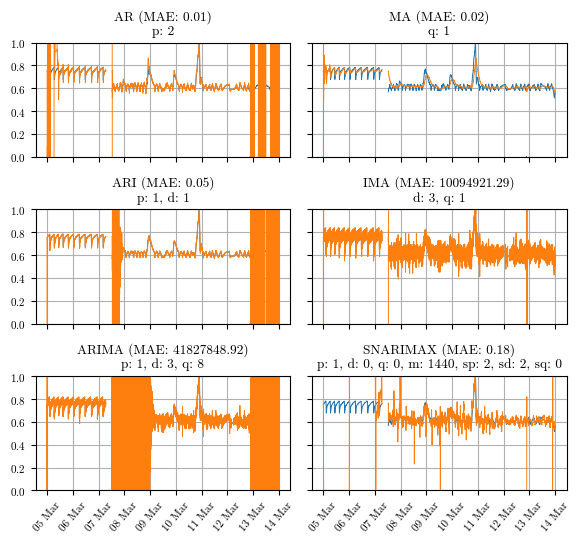

In [4]:
# FUNCTIONS
def get_time_features(_x: dict[str, float]) -> dict[str, float]:
    """Return an empty dict (time features unused in this experiment)."""
    return {}


# DETECTION ALGORITHMS
detection_algorithms = [
    (
        "AR",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX, d=0, q=0),
        ],
        {"SNARIMAX__p__round": 2},
    ),
    (
        "MA",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX, d=0, p=0),
        ],
        {"SNARIMAX__q__round": 1},
    ),
    (
        "ARI",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX, q=0),
        ],
        {
            "SNARIMAX__p__round": 1,
            "SNARIMAX__d__round": 1,
        },
    ),
    (
        "IMA",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX, p=0),
        ],
        {
            "SNARIMAX__d__round": 3,
            "SNARIMAX__q__round": 1,
        },
    ),
    (
        "ARIMA",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX),
        ],
        {
            "SNARIMAX__p__round": 1,
            "SNARIMAX__d__round": 3,
            "SNARIMAX__q__round": 8,
        },
    ),
    (
        "SNARIMAX",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            partial(time_series.SNARIMAX),
        ],
        {
            "SNARIMAX__p__round": 1,
            "SNARIMAX__d__round": 0,
            "SNARIMAX__q__round": 0,
            "SNARIMAX__m__round": 1440,
            "SNARIMAX__sp__round": 2,
            "SNARIMAX__sd__round": 2,
            "SNARIMAX__sq__round": 0,
        },
    ),
]


# DATASETS
df = pd.read_csv("data/data_BESS_norm.csv", index_col=0)
df.index = pd.to_datetime(df.index, utc=True)
df = df.rename(columns={"Avg. Cell Temperature": "is_anomaly"})

dataset = {
    "name": "terra",
    "data": df,
    "anomaly_col": "is_anomaly",
    "drop": None,
}

fig, axs = plt.subplots(
    3,
    2,
    figsize=set_size("thesis", subplots=(3 / 2.3, 2 / 2.3)),
    sharex=True,
    sharey=True,
)
axs = axs.flatten()
# RUN
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # PREPROCESS DATA
    df = dataset["data"]
    if isinstance(dataset["anomaly_col"], str):
        df = df.rename(columns={dataset["anomaly_col"]: "anomaly"})
    elif isinstance(dataset["anomaly_col"], pd.Series):
        df_y = dataset["anomaly_col"]
        df["anomaly"] = df_y.rename("anomaly").to_numpy()
    if dataset["drop"] is not None:
        df = df.drop(columns=dataset["drop"])

    df_ys = df[["anomaly"]].copy()
    # RUN EACH MODEL AGAINST DATASET
    for alg_no, alg in enumerate(detection_algorithms):
        # INITIALIZE OPTIMIZER
        params = convert_to_nested_dict(alg[2])
        model = build_model(alg[1], params)
        if hasattr(model, "seed"):
            model.seed = RANDOM_STATE
        if hasattr(model, "random_state"):
            model.random_state = RANDOM_STATE
        # USE TUNED MODEL
        # PROGRESSIVE PREDICT
        metrics = [
            MAE(),
        ]
        y_pred, _ = progressive_val_predict(
            model,
            df,
            metrics=metrics,
            period=5,
        )

        # LOAD RESULTS
        axs[alg_no].plot(df_ys.resample("1t").asfreq().anomaly, linewidth=0.7)
        axs[alg_no].plot(
            pd.DataFrame(y_pred, index=df.index).resample("1t").asfreq(),
            linewidth=0.7,
        )
        axs[alg_no].set_ylim(0, 1)
        axs[alg_no].set_title(
            (
                f"{alg[0]}"
                f" ({metrics[0].__class__.__name__}: {metrics[0].get():.2f})\n"
                f"{
                    ', '.join(
                        f'{k}: {v}' for k, v in params['SNARIMAX'].items()
                    )
                }"
            ),
        )
        axs[alg_no].xaxis.set_major_locator(locator)
        axs[alg_no].xaxis.set_major_formatter(formatter)
        axs[alg_no].tick_params(axis="x", labelrotation=50, labelsize=8)

fig.tight_layout()
fig.savefig("ARIMA_opt_results.pdf")


=== terra === [8197.166942148067/12497]========================================

===== AR=======================================================================
{'SNARIMAX': {'p': 2}}

===== MA=======================================================================
{'SNARIMAX': {'q': 1}}

===== ARI======================================================================
{'SNARIMAX': {'p': 1, 'd': 1}}

===== IMA======================================================================
{'SNARIMAX': {'d': 3, 'q': 1}}

===== ARIMA====================================================================
{'SNARIMAX': {'p': 1, 'd': 3, 'q': 8}}

===== SNARIMAX=================================================================
{'SNARIMAX': {'p': 1, 'd': 0, 'q': 0, 'm': 1440, 'sp': 2, 'sd': 2, 'sq': 0}}


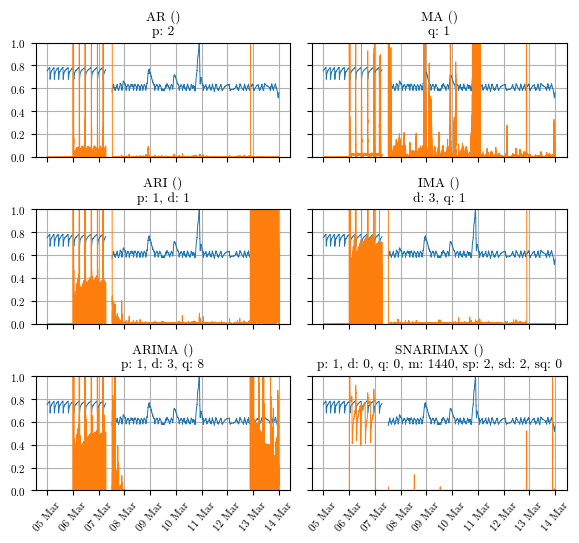

In [10]:
# FUNCTIONS
def get_time_features(_x: dict[str, float]) -> dict[str, float]:
    """Return an empty dict (time features unused in this experiment)."""
    return {}


# DETECTION ALGORITHMS
detection_algorithms = [
    (
        "AR",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            [
                partial(
                    anomaly.PredictiveAnomalyDetection,
                    warmup_period=24 * 60,
                ),
                partial(time_series.SNARIMAX, d=0, q=0),
            ],
        ],
        {"SNARIMAX__p__round": 2},
    ),
    (
        "MA",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            [
                partial(
                    anomaly.PredictiveAnomalyDetection,
                    warmup_period=24 * 60,
                ),
                partial(time_series.SNARIMAX, d=0, p=0),
            ],
        ],
        {"SNARIMAX__q__round": 1},
    ),
    (
        "ARI",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            [
                partial(
                    anomaly.PredictiveAnomalyDetection,
                    warmup_period=24 * 60,
                ),
                partial(time_series.SNARIMAX, q=0),
            ],
        ],
        {
            "SNARIMAX__p__round": 1,
            "SNARIMAX__d__round": 1,
        },
    ),
    (
        "IMA",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            [
                partial(
                    anomaly.PredictiveAnomalyDetection,
                    warmup_period=24 * 60,
                ),
                partial(time_series.SNARIMAX, p=0),
            ],
        ],
        {
            "SNARIMAX__d__round": 3,
            "SNARIMAX__q__round": 1,
        },
    ),
    (
        "ARIMA",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            [
                partial(
                    anomaly.PredictiveAnomalyDetection,
                    warmup_period=24 * 60,
                ),
                partial(time_series.SNARIMAX),
            ],
        ],
        {
            "SNARIMAX__p__round": 1,
            "SNARIMAX__d__round": 3,
            "SNARIMAX__q__round": 8,
        },
    ),
    (
        "SNARIMAX",
        [
            partial(compose.FuncTransformer, func=get_time_features),
            [
                partial(
                    anomaly.PredictiveAnomalyDetection,
                    warmup_period=24 * 60,
                ),
                partial(time_series.SNARIMAX),
            ],
        ],
        {
            "SNARIMAX__p__round": 1,
            "SNARIMAX__d__round": 0,
            "SNARIMAX__q__round": 0,
            "SNARIMAX__m__round": 1440,
            "SNARIMAX__sp__round": 2,
            "SNARIMAX__sd__round": 2,
            "SNARIMAX__sq__round": 0,
        },
    ),
]


# DATASETS
df = pd.read_csv("data/data_BESS_norm.csv", index_col=0)
df.index = pd.to_datetime(df.index, utc=True)
df = df.rename(columns={"Avg. Cell Temperature": "is_anomaly"})

dataset = {
    "name": "terra",
    "data": df,
    "anomaly_col": "is_anomaly",
    "drop": None,
}

fig, axs = plt.subplots(
    3,
    2,
    figsize=set_size("thesis", subplots=(3 / 2.3, 2 / 2.3)),
    sharex=True,
    sharey=True,
)
axs = axs.flatten()
# RUN
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # PREPROCESS DATA
    df = dataset["data"]
    if isinstance(dataset["anomaly_col"], str):
        df = df.rename(columns={dataset["anomaly_col"]: "anomaly"})
    elif isinstance(dataset["anomaly_col"], pd.Series):
        df_y = dataset["anomaly_col"]
        df["anomaly"] = df_y.rename("anomaly").to_numpy()
    if dataset["drop"] is not None:
        df = df.drop(columns=dataset["drop"])

    df_ys = df[["anomaly"]].copy()
    # RUN EACH MODEL AGAINST DATASET
    for alg_no, alg in enumerate(detection_algorithms):
        # INITIALIZE OPTIMIZER
        params = convert_to_nested_dict(alg[2])
        model = build_model(alg[1], params)
        if hasattr(model, "seed"):
            model.seed = RANDOM_STATE
        if hasattr(model, "random_state"):
            model.random_state = RANDOM_STATE
        # USE TUNED MODEL
        # PROGRESSIVE PREDICT
        metrics = [
            MAE(),
        ]
        y_pred = []
        for x, y in df.anomaly.items():
            _x = {"month": x}
            score = model.score_one(None, y=y)
            model.learn_one(None, y=y)
            y_pred.append(score)

        # LOAD RESULTS
        axs[alg_no].plot(df_ys.resample("1t").asfreq().anomaly, linewidth=0.7)
        axs[alg_no].plot(
            pd.DataFrame(y_pred, index=df.index).resample("1t").asfreq(),
            linewidth=0.7,
        )
        axs[alg_no].set_ylim(0, 1)
        axs[alg_no].set_title(
            f"{alg[0]} ()\n"
            f"{', '.join(f'{k}: {v}' for k, v in params['SNARIMAX'].items())}",
        )
        axs[alg_no].xaxis.set_major_locator(locator)
        axs[alg_no].xaxis.set_major_formatter(formatter)
        axs[alg_no].tick_params(axis="x", labelrotation=50, labelsize=8)

fig.tight_layout()
fig.savefig("ARIMA_opt_scores.pdf")